In [ ]:
!pip install pandas --upgrade
!pip install matplotlib --upgrade
!pip install seaborn --upgrade

^C


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
m = pd.read_csv("simulation_results/metrics_20250913_124425.csv")

In [3]:
# Filter for packet_arrived
arrived = m[m['type'] == 'packet_arrived'].copy()
# Convert to datetime if not already
arrived['creation_time'] = pd.to_datetime(arrived['creation_time'])
arrived['deliver_time'] = pd.to_datetime(arrived['deliver_time'])
# Calculate latency in seconds
arrived['latency_sec'] = (arrived['deliver_time'] - arrived['creation_time']).dt.total_seconds()

## Average Latency

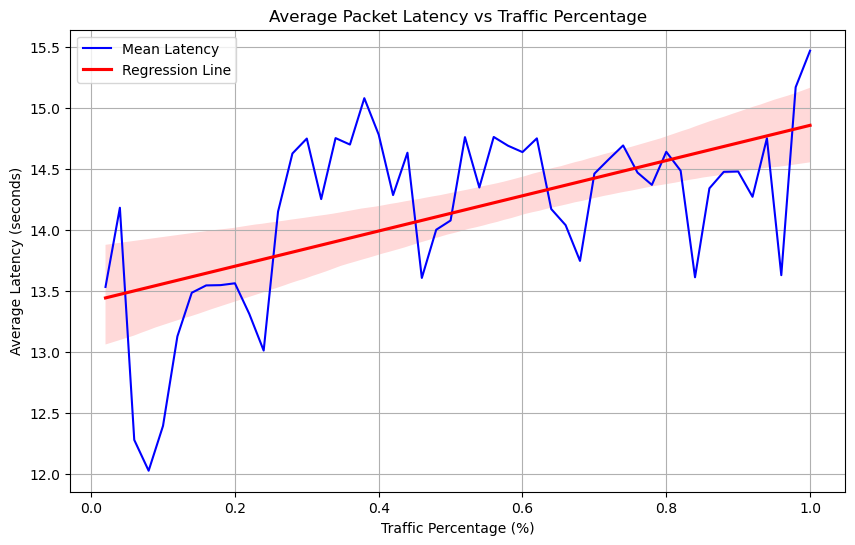

In [4]:
# Show the result
latency = arrived.groupby('traffic').agg({'latency_sec': ['mean', 'std', 'min', 'max']})

plt.figure(figsize=(10, 6))

# Plot only points
plt.plot(latency.index, latency['latency_sec']['mean'], label='Mean Latency', color='b')
# Regression line (order 1 = linear)
sns.regplot(x=latency.index, y=latency['latency_sec']['mean'], scatter=False, order=1, color='r', label='Regression Line')
plt.title('Average Packet Latency vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Average Latency (seconds)')
plt.grid(True)
plt.legend()
plt.show()

## Extra Delay

C:\Users\igorf\AppData\Local\Temp\ipykernel_19644\2307676736.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extra_delay = pd.merge(arrived, min_latency, on='traffic', how='left').fillna(0)


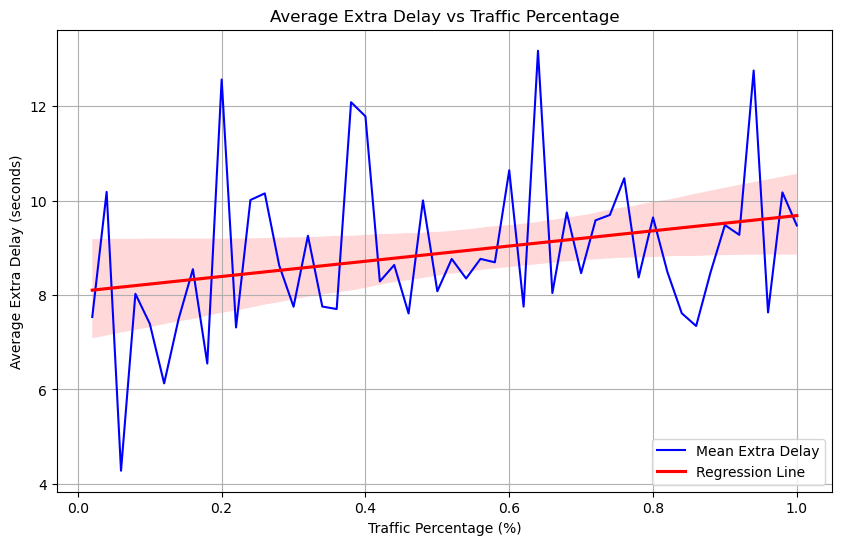

In [5]:
# Get the minimum latency
min_latency = latency['latency_sec']['min'].reset_index(name='min_latency')
# Calculate the extra delay by subtracting the minimum latency from the average latency
extra_delay = pd.merge(arrived, min_latency, on='traffic', how='left').fillna(0)
extra_delay['extra_delay_sec'] = extra_delay['latency_sec'] - extra_delay['min_latency']
# Plot the extra delay
extra_delay_summary = extra_delay.groupby('traffic').agg({'extra_delay_sec': ['mean', 'std', 'min', 'max']})

plt.figure(figsize=(10, 6))
# Plot only points
plt.plot(extra_delay_summary.index, extra_delay_summary['extra_delay_sec']['mean'], label='Mean Extra Delay', color='b')
# Regression line (order 1 = linear)
sns.regplot(x=extra_delay_summary.index, y=extra_delay_summary['extra_delay_sec']['mean'], scatter=False, order=1, color='r', label='Regression Line')

plt.title('Average Extra Delay vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Average Extra Delay (seconds)')
plt.grid(True)
plt.legend()
plt.show()

## Packet Loss

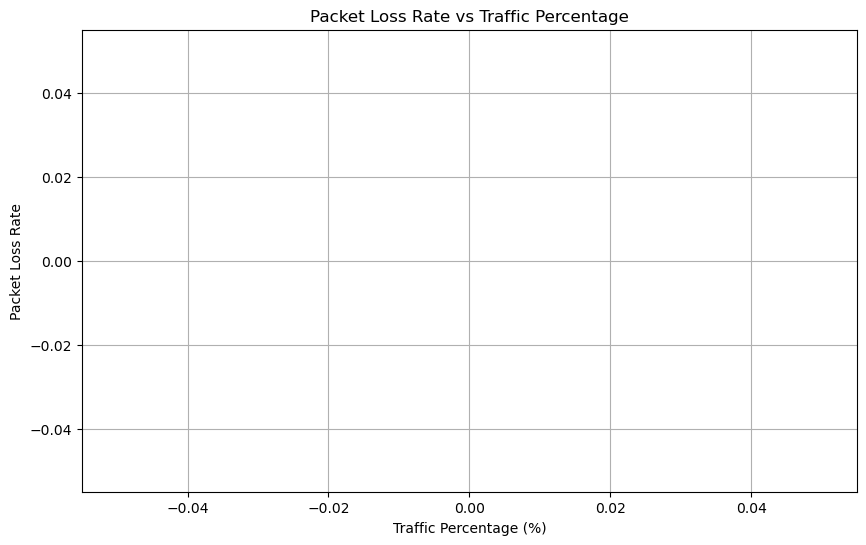

In [20]:
# Filter for packet_loss
loss = m[m['type'] == 'packet_loss'].copy()
# Get the total packets sent per traffic level
total_sent = m[m['type'] == 'packet_sent'].groupby('traffic').size().reset_index(name='total_sent')
# Get the total packets lost per traffic level
total_lost = loss.groupby('traffic').size().reset_index(name='total_lost')
# Merge the two dataframes
loss_stats = pd.merge(total_sent, total_lost, on='traffic', how='left').fillna(0)
# Calculate loss rate
loss_stats['loss_rate'] = loss_stats['total_lost'] / loss_stats['total_sent']
# Plot loss rate
plt.figure(figsize=(10, 6))
plt.plot(loss_stats['traffic'], loss_stats['loss_rate'], marker='o')
plt.title('Packet Loss Rate vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Packet Loss Rate')
plt.grid(True)
plt.show()